# EDA: Forest Sound Dataset

Notebook นี้สำรวจโครงสร้าง dataset เสียงป่า ตรวจสอบไฟล์เสีย ความยาวเสียง และ sample rate พร้อมแสดงการกระจายของคลาสและตัวอย่าง waveform / Mel-Spectrogram

> โครงสร้างที่คาดหวัง: `forest_sound_dataset/{fire,logging,natural sound,poaching}`

ถ้าเปิด Notebook จากโฟลเดอร์อื่น ตัวแปร `DATASET_DIR` จะค้นหาโฟลเดอร์ dataset จากตำแหน่งปัจจุบันและจาก parent ของโฟลเดอร์ `notebooks` อัตโนมัติ

In [1]:
from pathlib import Path
import warnings

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

EXPECTED_CLASSES = ["fire", "logging", "natural sound", "poaching"]
AUDIO_EXTENSIONS = {".wav", ".wave", ".aiff", ".aif", ".flac", ".mp3", ".m4a", ".ogg", ".opus", ".aac", ".wma"}

def find_dataset_dir():
    candidates = [
        Path("forest_sound_dataset"),
        Path.cwd() / "forest_sound_dataset",
        Path.cwd().parent / "forest_sound_dataset",
        Path.cwd().parent.parent / "forest_sound_dataset",
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError("ไม่พบโฟลเดอร์ forest_sound_dataset")

DATASET_DIR = find_dataset_dir()
print(f"Dataset: {DATASET_DIR}")

Matplotlib is building the font cache; this may take a moment.


Dataset: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/forest_sound_dataset


## 1. ตรวจโครงสร้างและจำนวนไฟล์ในแต่ละคลาส

In [2]:
class_dirs = {name: DATASET_DIR / name for name in EXPECTED_CLASSES}
structure_rows = []
for class_name, class_dir in class_dirs.items():
    files = sorted(p for p in class_dir.rglob("*") if p.is_file()) if class_dir.exists() else []
    audio_files = [p for p in files if p.suffix.lower() in AUDIO_EXTENSIONS]
    structure_rows.append({
        "class": class_name,
        "directory_exists": class_dir.exists(),
        "all_files": len(files),
        "audio_files": len(audio_files),
        "other_files": len(files) - len(audio_files),
    })

structure_df = pd.DataFrame(structure_rows)
display(structure_df)

audio_paths = []
for class_name, class_dir in class_dirs.items():
    if class_dir.exists():
        audio_paths.extend((class_name, p) for p in sorted(class_dir.rglob("*"))
                            if p.is_file() and p.suffix.lower() in AUDIO_EXTENSIONS)
print(f"รวมไฟล์เสียง: {len(audio_paths):,} ไฟล์")

,class,directory_exists,all_files,audio_files,other_files
0,fire,True,336,336,0
1,logging,True,455,455,0
2,natural sound,True,1363,1363,0
3,poaching,True,608,608,0


รวมไฟล์เสียง: 2,762 ไฟล์


## 2. ตรวจไฟล์เสีย ความยาวเสียง และ sample rate

In [3]:
def inspect_audio(class_name, path):
    record = {"class": class_name, "file": str(path.relative_to(DATASET_DIR)), "path": str(path),
              "format": path.suffix.lower().lstrip("."), "sample_rate": np.nan,
              "duration_sec": np.nan, "channels": np.nan, "status": "ok", "error": ""}
    try:
        # soundfile reads metadata without loading the complete signal (WAV/FLAC/etc.)
        try:
            info = sf.info(path)
            record.update(sample_rate=info.samplerate, duration_sec=info.duration, channels=info.channels)
        except Exception:
            # Fallback for formats such as M4A/MP3 supported by librosa/audioread.
            signal, sample_rate = librosa.load(path, sr=None, mono=False)
            record.update(sample_rate=sample_rate, duration_sec=signal.shape[-1] / sample_rate,
                          channels=1 if signal.ndim == 1 else signal.shape[0])
        if not np.isfinite(record["duration_sec"]) or record["duration_sec"] <= 0:
            raise ValueError("เสียงมีความยาวไม่ถูกต้อง")
    except Exception as exc:
        record.update(status="error", error=f"{type(exc).__name__}: {exc}")
    return record

records = [inspect_audio(class_name, path) for class_name, path in audio_paths]
audio_df = pd.DataFrame(records)
print(f"ตรวจแล้ว {len(audio_df):,} ไฟล์ | ปกติ: {(audio_df.status == 'ok').sum():,} | เสีย/อ่านไม่ได้: {(audio_df.status == 'error').sum():,}")
display(audio_df.head())

bad_files = audio_df[audio_df.status == "error"]
if bad_files.empty:
    print("ไม่พบไฟล์เสียหรือไฟล์ที่อ่านไม่ได้")
else:
    display(bad_files[["class", "file", "error"]])

ตรวจแล้ว 2,762 ไฟล์ | ปกติ: 2,761 | เสีย/อ่านไม่ได้: 1


,class,file,path,format,sample_rate,duration_sec,channels,status,error
0,fire,fire/1-17150-A-12.wav,/Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Soun...,wav,44100.0,5.0,1.0,ok,
1,fire,fire/1-17565-A-12.wav,/Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Soun...,wav,44100.0,5.0,1.0,ok,
2,fire,fire/1-17742-A-12.wav,/Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Soun...,wav,44100.0,5.0,1.0,ok,
3,fire,fire/1-17808-A-12.wav,/Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Soun...,wav,44100.0,5.0,1.0,ok,
4,fire,fire/1-17808-B-12.wav,/Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Soun...,wav,44100.0,5.0,1.0,ok,


,class,file,error
117,fire,fire/755366__goochiano__wild-fire.m4a,LibsndfileError: Error opening '/Users/guidegi...


In [4]:
valid_audio_df = audio_df[audio_df.status == "ok"].copy()
if not valid_audio_df.empty:
    summary_df = (valid_audio_df.groupby("class")
                  .agg(files=("file", "count"),
                       duration_min_sec=("duration_sec", "min"),
                       duration_mean_sec=("duration_sec", "mean"),
                       duration_max_sec=("duration_sec", "max"),
                       sample_rates=("sample_rate", lambda x: sorted(x.dropna().unique().tolist())))
                  .reindex(EXPECTED_CLASSES))
    display(summary_df.round(2))
    print("จำนวน sample rate ที่พบในแต่ละคลาส:")
    display(valid_audio_df.groupby("class")["sample_rate"].value_counts().rename("files").reset_index())
else:
    print("ไม่มีไฟล์เสียงที่ตรวจสอบผ่านสำหรับสรุปสถิติ")

,files,duration_min_sec,duration_mean_sec,duration_max_sec,sample_rates
class,,,,,
fire,335,0.38,35.17,173.0,"[44100.0, 48000.0, 192000.0]"
logging,455,5.00,5.00,5.0,"[11025.0, 16000.0, 24000.0, 44100.0, 48000.0, ..."
natural sound,1363,5.00,5.00,5.0,"[8000.0, 11025.0, 16000.0, 22050.0, 32000.0, 4..."
poaching,608,0.50,3.80,5.0,"[8000.0, 16000.0, 44100.0, 48000.0, 88200.0, 9..."


จำนวน sample rate ที่พบในแต่ละคลาส:


,class,sample_rate,files
0,fire,44100.0,302
1,fire,48000.0,32
2,fire,192000.0,1
3,logging,48000.0,166
4,logging,44100.0,148
5,logging,24000.0,134
6,logging,96000.0,5
7,logging,11025.0,1
8,logging,16000.0,1
9,natural sound,44100.0,689


## 3. กราฟจำนวนไฟล์เสียงแต่ละคลาส

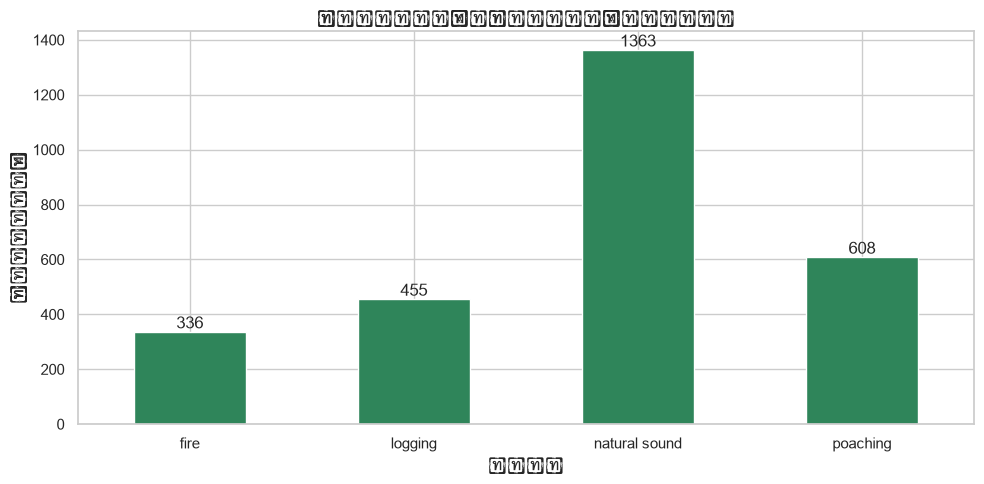

In [5]:
counts = structure_df.set_index("class").reindex(EXPECTED_CLASSES)["audio_files"]
ax = counts.plot(kind="bar", color="#2f855a", figsize=(10, 5), rot=0)
ax.set_title("จำนวนไฟล์เสียงในแต่ละคลาส")
ax.set_xlabel("คลาส")
ax.set_ylabel("จำนวนไฟล์")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()
plt.show()

## 4. ตัวอย่าง Waveform และ Mel-Spectrogram ของแต่ละคลาส

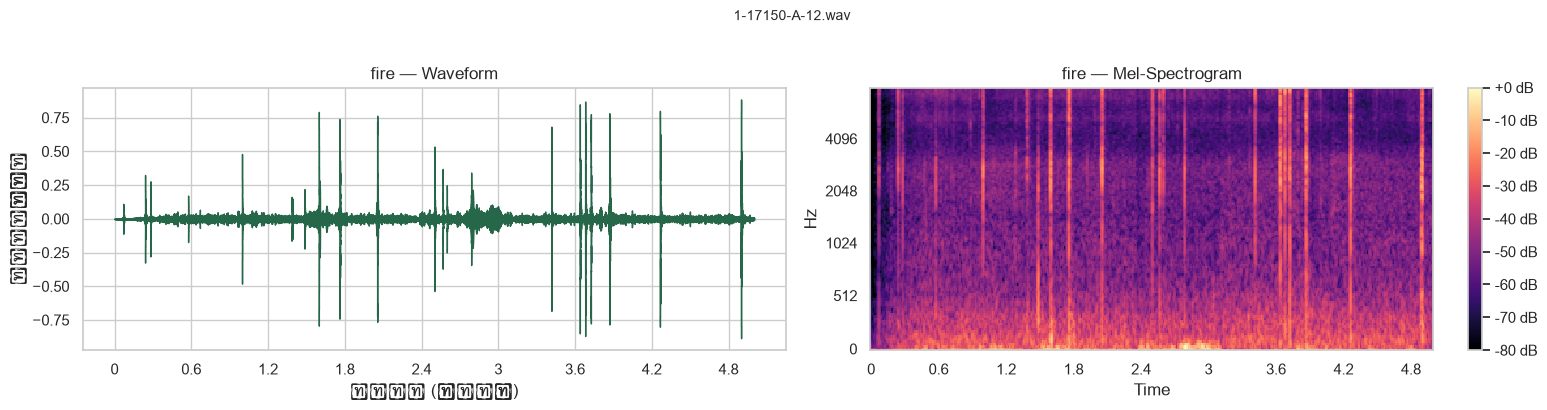

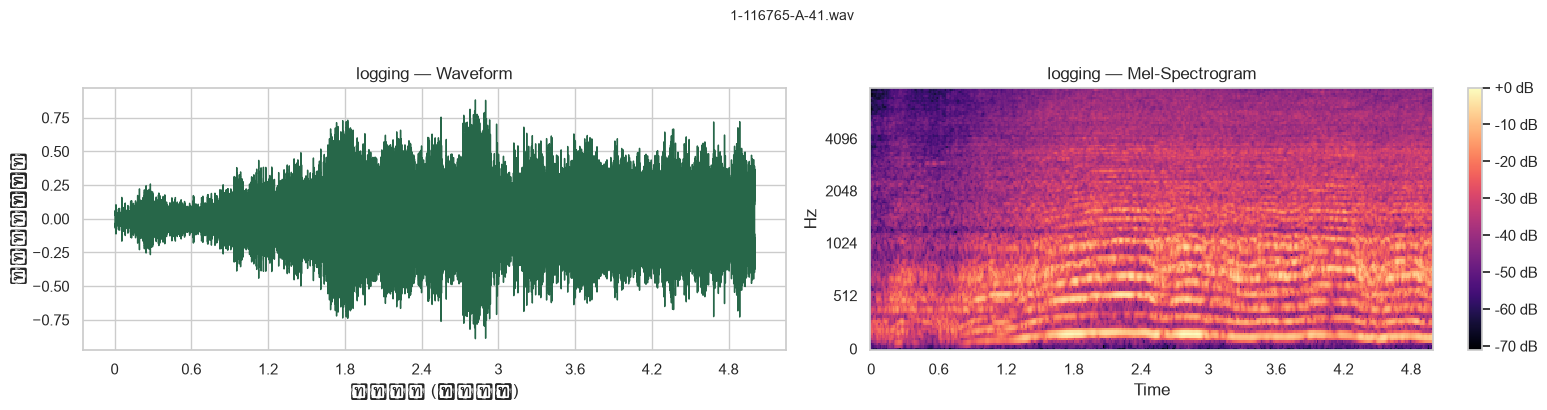

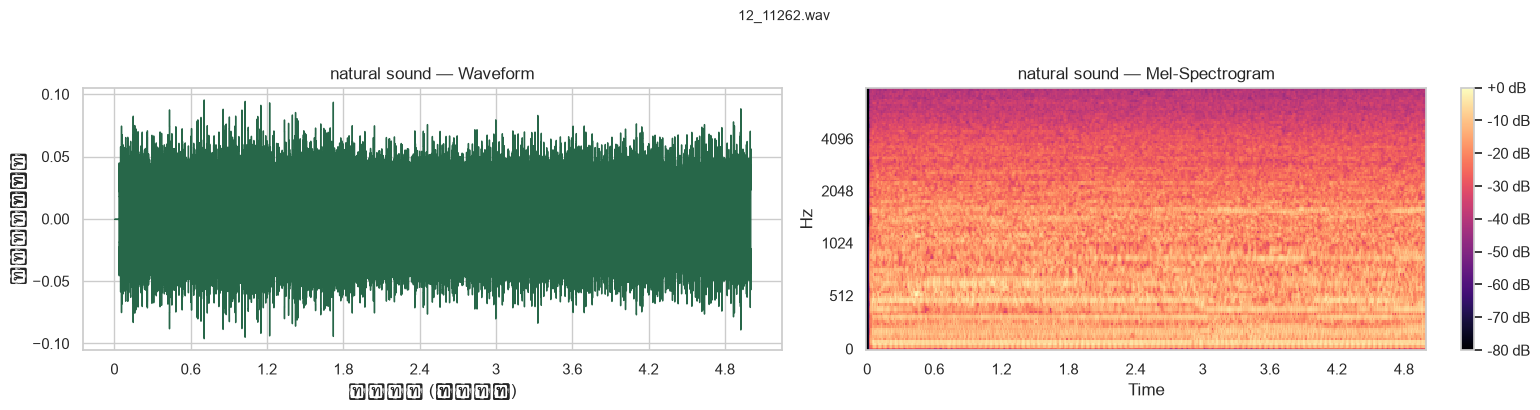

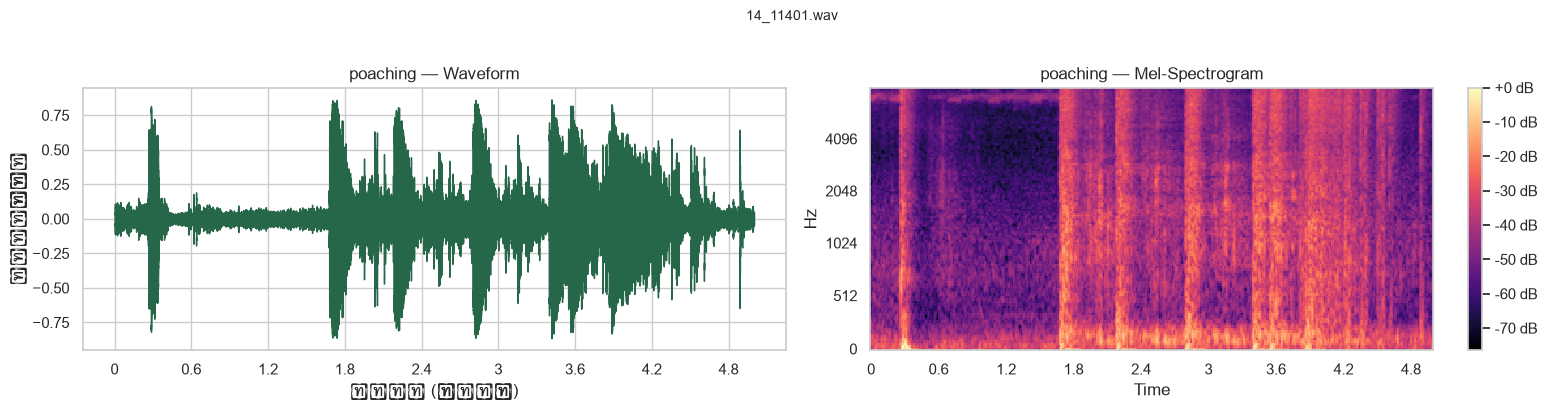

In [6]:
def choose_example(class_name):
    candidates = [(c, p) for c, p in audio_paths if c == class_name]
    valid = valid_audio_df[valid_audio_df["class"] == class_name]
    if valid.empty:
        return candidates[0][1] if candidates else None
    return DATASET_DIR / valid.iloc[0]["file"]

for class_name in EXPECTED_CLASSES:
    example_path = choose_example(class_name)
    if example_path is None:
        print(f"ข้าม {class_name}: ไม่พบไฟล์เสียง")
        continue
    try:
        y, sr = librosa.load(example_path, sr=None, mono=True)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=min(8000, sr // 2))
        mel_db = librosa.power_to_db(mel, ref=np.max)
        fig, axes = plt.subplots(1, 2, figsize=(16, 4))
        librosa.display.waveshow(y, sr=sr, ax=axes[0], color="#276749")
        axes[0].set_title(f"{class_name} — Waveform")
        axes[0].set_xlabel("เวลา (วินาที)")
        axes[0].set_ylabel("แอมพลิจูด")
        img = librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", fmax=min(8000, sr // 2), ax=axes[1], cmap="magma")
        axes[1].set_title(f"{class_name} — Mel-Spectrogram")
        fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
        fig.suptitle(example_path.name, y=1.02, fontsize=10)
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"แสดงตัวอย่าง {class_name} ไม่สำเร็จ: {example_path} — {exc}")

## สรุป

ผลตรวจสอบหลักอยู่ใน `structure_df`, `audio_df`, `bad_files` และ `valid_audio_df` สามารถนำ DataFrame เหล่านี้ไปใช้ต่อในการทำความสะอาดข้อมูลหรือเตรียม train/validation split ได้